# Libraries

Before run this notebook you need install the dependencies. See the `requirements.txt` file.


In [36]:
from functions_victor_project import *

import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from UQpy.distributions import Uniform, Normal, JointIndependent #, Lognormal
from UQpy.distributions.collection.Lognormal import Lognormal
from UQpy.surrogates import *
from sklearn.metrics import mean_squared_error, r2_score

# Statistics of the input variables

- $R$: Resistance variable  
- $S$: Demand variable  
- $Z_1$ and $Z_2$: Latent variables  

State Limit Function:

$$
g(R, S, t) = R(t) - log(Z_1) - (S + log(Z_2))
$$

**Table 1:** Moments, distributions, and parameters of the considered variables for the $R$ and $S$ problem.

| Variable | Distribution | Mean | Std. Deviation |  
|----------|--------------|------|----------------|  
| $R$    | Normal     | 5.0  | 0.8            |  
| $S$    | Normal     | 2.0  | 0.6            |  
| $Z_1$ | Lognormal   | 1.0  | 0.028          |  
| $Z_2$ | Lognormal   | 1.0  | 0.096          |  

To simulate $Z_1$ and $Z_2$ we are used `scipy` library. You can see the file `glam_example_1.py` and how to generate state limit results. 

### Transformation to scipy parameters

**Shape parameter (s):**
$$
s = \sqrt{\ln\left(1 + \left(\frac{\sigma}{\mu}\right)^2\right)}
$$

**Scale parameter:**
$$
\text{scale} = \frac{\mu}{\sqrt{1 + \left(\frac{\sigma}{\mu}\right)^2}}
$$

Where:
- $\mu$ = mean of the lognormal distribution  
- $\sigma$ = standard deviation of the lognormal distribution
- $s$ = shape parameter for `scipy.stats.lognorm`
- $\text{scale}$ = scale parameter for `scipy.stats.lognorm`

# Samples

We use $n_{samples}$ as number of samples and $n_{latent,samples}$ stands a number of latent samples.

In [37]:
n_samples = 100
n_latent_samples = 200

### Generating samples

In [38]:
r   = Normal(loc = 5., scale=0.8)
s   = Normal(loc = 2., scale=0.6)
joint = JointIndependent(marginals=[r, s])
x = joint.rvs(n_samples)
x

array([[4.77563374, 1.06803081],
       [3.52257152, 2.29439066],
       [5.02406903, 1.66783001],
       [4.56647186, 2.05378961],
       [6.12517649, 1.16601883],
       [4.39359861, 1.74943396],
       [5.9423047 , 1.97058058],
       [3.99846413, 2.27877658],
       [4.98932602, 1.26366241],
       [5.31731539, 2.86658085],
       [5.06267267, 2.25603671],
       [6.23440874, 2.38959954],
       [4.73437044, 2.17413545],
       [4.15599998, 2.07035607],
       [6.80278728, 2.4517605 ],
       [4.89813543, 1.54945672],
       [5.41412878, 2.73633882],
       [5.83192706, 3.05670102],
       [3.61177421, 2.64760645],
       [3.43211155, 2.63878562],
       [6.40525239, 3.04315863],
       [3.60861916, 2.18271258],
       [5.77722303, 1.08077322],
       [5.82596877, 1.73486178],
       [4.42958317, 1.94711049],
       [5.6031848 , 3.20230272],
       [4.32215787, 1.04035928],
       [5.04196369, 1.94717429],
       [6.37022683, 1.93100362],
       [5.75765339, 2.6641006 ],
       [3.

### Computing output values

In [39]:
y, _ = state_limit_function(x, n_latent_samples)
y

array([[ 3.70370239e+00,  9.23939775e+00,  1.23926964e-01,
         5.42262801e-03],
       [ 1.29089106e+00,  6.00630748e+00,  3.71843807e-02,
         2.91573895e-01],
       [ 3.38429982e+00,  6.34388082e+00,  1.71500680e-01,
         1.44220792e-01],
       [ 2.53474971e+00,  6.65820001e+00,  1.13789059e-02,
         1.59311992e-01],
       [ 4.98261806e+00,  7.98613140e+00,  1.61322547e-02,
         2.63396980e-02],
       [ 2.65471661e+00,  6.25946551e+00,  1.88251777e-01,
         2.44217026e-01],
       [ 3.96887645e+00,  5.07146803e+00,  2.25192821e-01,
         1.53235205e-01],
       [ 1.72110426e+00,  6.14543258e+00,  3.29265537e-02,
         1.38307959e-01],
       [ 3.71794829e+00,  7.66960621e+00,  1.10127251e-01,
         1.14463507e-01],
       [ 2.47351785e+00,  4.34990843e+00,  1.43211726e-01,
         2.56565947e-01],
       [ 2.83503709e+00,  4.71530633e+00,  2.23856723e-01,
         3.50865658e-01],
       [ 3.85398832e+00,  4.89694514e+00,  2.25662281e-01,
      

# Training with PCE

### Check dimensions

In [40]:
print("xx shape:", x.shape)
print("yy shape:", y.shape)

xx shape: (100, 2)
yy shape: (100, 4)


### Train

Using PCE with 4 degrees and Least Square Regression to fit a hyperparameters.

In [ ]:
max_degree = 3

In [42]:
polynomial_basis = TotalDegreeBasis(joint, max_degree)
least_squares = LeastSquareRegression()
pce_metamodel = PolynomialChaosExpansion(polynomial_basis=polynomial_basis, regression_method=least_squares)
pce_metamodel.fit(x, y)

### Coefficients

In [43]:
# pce_metamodel.coefficients
a = pce_metamodel.polynomial_basis.evaluate_basis(np.array([[5.0, 2.0]]))
a

array([[ 1.        ,  0.        ,  0.        , -0.70710678,  0.        ,
        -0.70710678, -0.        , -0.        , -0.        , -0.        ]])

In [59]:
c = pce_metamodel.coefficients
c

array([[ 3.01432957e+00,  6.18464778e+00,  1.33304473e-01,
         1.85396779e-01],
       [ 8.01742644e-01, -3.81033769e-01,  3.13288684e-03,
        -7.41702892e-03],
       [-5.94764371e-01, -1.01641820e+00, -3.42153669e-02,
        -1.34957632e-03],
       [-3.38247797e-04,  1.55309745e-01,  5.10031034e-03,
        -4.59731726e-04],
       [-1.13908549e-03,  2.77476617e-01,  2.56416524e-04,
        -3.01787939e-03],
       [-1.61721184e-03,  1.45062692e-01, -2.14648472e-03,
        -9.89946889e-03],
       [ 2.33113716e-04,  1.11352669e-01, -2.48283075e-02,
        -9.05058419e-03],
       [-1.59619145e-05, -2.32713202e-01,  1.21795872e-02,
         1.43440492e-02],
       [-1.40011286e-04, -7.35935351e-02, -5.58831848e-03,
        -2.38150908e-03],
       [-9.47674230e-04,  5.62210908e-02, -5.37178042e-03,
        -7.88889759e-03]])

In [45]:
y = a.dot(c)
y

array([[3.01571229, 5.97225239, 0.1312158 , 0.19272184]])

### Validation

In [46]:
r   = Normal(loc = 5., scale=0.8)
s   = Normal(loc = 2., scale=0.6)
joint = JointIndependent(marginals=[r, s])
x_val = joint.rvs(n_samples)
y_val_obs, final_df = state_limit_function(x_val, n_latent_samples)

In [47]:
y_val_obs[0, :]

array([2.80851452, 9.67420533, 0.11794452, 0.15588505])

### Check dataframe format and one sample of state limit function

Here I check the format of one sample of the $R$ and $S$ variables. I used the KDE histogram plot. In this case I checked `0` row.

In [48]:
final_df[0].head()

,r,s,z1,z2,g
0,4.03303,1.229152,1.027682,0.851528,2.877738
1,4.03303,1.229152,0.983795,0.973803,2.902510
2,4.03303,1.229152,0.972915,0.943323,2.985818
3,4.03303,1.229152,0.956215,0.915447,3.092476
4,4.03303,1.229152,1.015420,0.948685,2.805707


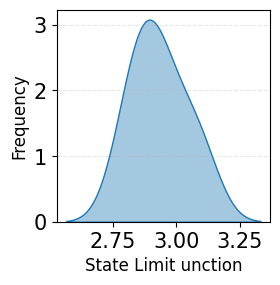

In [49]:
data = final_df[0].head()
ratio_data = data['g']

# Figure Size in Centimeters
width_cm = 7
height_cm = 7
inches_per_cm = 1 / 2.54
width_in = width_cm * inches_per_cm
height_in = height_cm * inches_per_cm

y_axis_label = 'State Limit unction'
label_size = 12
label_color = 'black'

# KDE Plot
plt.figure(figsize=(width_in, height_in))
sns.kdeplot(data=ratio_data, fill=True, alpha=0.4)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlabel(y_axis_label, fontsize=label_size, color=label_color)
plt.ylabel('Frequency', fontsize=label_size, color=label_color)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()
# plt.savefig('state_limit_funciton_histogram_one_sample.png', dpi=600)

### Evaluation x_val using PCE model

In [50]:
y_val_pre = pce_metamodel.predict(x_val)

In [51]:
y_val_pre[0, :]

array([2.80643535, 8.78239471, 0.14943633, 0.16859559])

In [52]:
test_lambda_values = list(y_val_pre[0, :])
test_lambda_values

[2.806435350345247, 8.782394705361018, 0.1494363322593098, 0.16859558554310103]

### Scatter plot

#### Dataset of first moment of GLAM

In [53]:
y_val_obs_aux = list(y_val_obs[:, 0])
y_val_pre_aux = list(y_val_pre[:, 0])                 

#### Scatter image

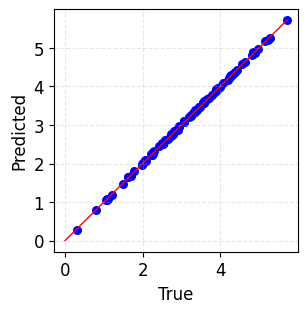

In [54]:
# Figure dimension
width_cm = 8
height_cm = 8
inches_per_cm = 1 / 2.54
width_in = width_cm * inches_per_cm
height_in = height_cm * inches_per_cm

# Labels properties
label_x = 'True'
label_y = 'Predicted'
label_size = 12
axis_size = 12
label_color = 'black'

# Scatter Plot
point_size = 30
color_scatter = 'blue'
plt.figure(figsize=(width_in, height_in))
plt.scatter(y_val_obs_aux, y_val_pre_aux,
            s=point_size,
            c=color_scatter)

# Regression Line
regression_line_color = 'red'
regression_line_style = '-'
regression_line_width = 1
x_line = np.array([0, max(y_val_obs_aux)])
y_line = x_line
plt.plot(x_line, y_line,
         color=regression_line_color,
         linestyle=regression_line_style,
         linewidth=regression_line_width,
         zorder=1)

plt.tick_params(axis='both', which='major', labelsize=axis_size)
plt.xlabel(label_x, fontsize=label_size, color=label_color)
plt.ylabel(label_y, fontsize=label_size, color=label_color)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()
# plt.savefig('validation_scatter_train.png', dpi=600)

### All $\lambda$ GLAM parameters

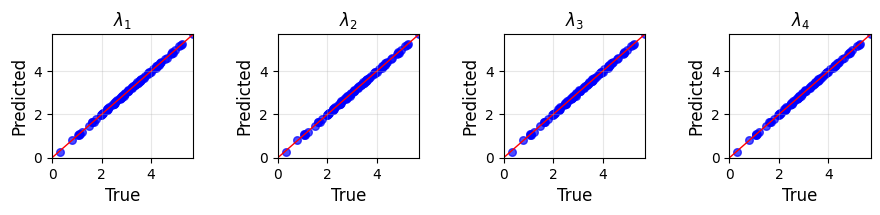

In [55]:
# Data for the 4 charts (replace with your actual data)
y_val_obs_aux1 = list(y_val_obs[:, 0])
y_val_pre_aux1 = list(y_val_pre[:, 0])    
y_val_obs_aux2 = list(y_val_obs[:, 0])
y_val_pre_aux2 = list(y_val_pre[:, 0])   
y_val_obs_aux3 = list(y_val_obs[:, 0])
y_val_pre_aux3 = list(y_val_pre[:, 0])   
y_val_obs_aux4 = list(y_val_obs[:, 0])
y_val_pre_aux4 = list(y_val_pre[:, 0])   
datasets = [
    (y_val_obs_aux1, y_val_pre_aux1, '$\lambda _1$'),
    (y_val_obs_aux2, y_val_pre_aux2, '$\lambda _2$'),
    (y_val_obs_aux3, y_val_pre_aux3, '$\lambda _3$'),
    (y_val_obs_aux4, y_val_pre_aux4, '$\lambda _4$'),
]

# Figure dimensions for 4 charts in a row
width_cm_per_chart = 6
height_cm = 6
inches_per_cm = 1 / 2.54
width_in_total = width_cm_per_chart * 4 * inches_per_cm  # Total width for 4 charts
height_in = height_cm * inches_per_cm

# Labels properties
label_x = 'True'
label_y = 'Predicted'
label_size = 12
axis_size = 10
label_color = 'black'

# Scatter plot settings
point_size = 30
color_scatter = 'blue'

# Regression line settings
regression_line_color = 'red'
regression_line_style = '-'
regression_line_width = 1

# Create figure with subplots
fig, axes = plt.subplots(1, 4, figsize=(width_in_total, height_in))
fig.tight_layout(pad=3.0)  # Add padding between subplots

# Plot each dataset in its own subplot
for i, (y_obs, y_pred, title) in enumerate(datasets):
    ax = axes[i]
    
    # Scatter plot
    ax.scatter(y_obs, y_pred,
               s=point_size,
               c=color_scatter,
               alpha=0.7)
    
    # Regression line (y = x)
    x_line = np.array([0, max(y_obs)])
    y_line = x_line
    ax.plot(x_line, y_line,
            color=regression_line_color,
            linestyle=regression_line_style,
            linewidth=regression_line_width,
            zorder=1)
    
    # Customize each subplot
    ax.tick_params(axis='both', which='major', labelsize=axis_size)
    ax.set_xlabel(label_x, fontsize=label_size, color=label_color)
    ax.set_ylabel(label_y, fontsize=label_size, color=label_color)
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=label_size)
    
    # Set consistent axis limits for better comparison
    max_val = max(max(y_obs), max(y_pred))
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)

plt.show()
# plt.savefig('validation_scatter_train_all_lambdas.png', dpi=600)

#### Scores

In [56]:
print("R2:", r2_score(y_val_obs_aux, y_val_pre_aux))
print("MSE:", mean_squared_error(y_val_obs_aux, y_val_pre_aux))

R2: 0.9996806765704797
MSE: 0.0003910435090055274


#### Compare g state limit function and GLAM emulator

In [57]:
def plot_gld_vs_data(lambdas, n_points=5000, quantile_trim=1e-3, qp_min=1e-8, ylim=None):
    l1, l2, l3, l4 = lambdas

    # Curva da PDF GLD (robusta para evitar explosões numéricas)
    a = float(quantile_trim)
    u = np.linspace(a, 1.0 - a, n_points)
    x = gld_fkml_quantile(u, l1, l2, l3, l4)
    qp = gld_fkml_qprime(u, l2, l3, l4)

    mask = np.isfinite(x) & np.isfinite(qp) & (qp > qp_min)
    x, f = x[mask], (1.0 / qp[mask])

    order = np.argsort(x)
    x, f = x[order], f[order]

    return list(x), list(f)

glam_data, _ = plot_gld_vs_data(test_lambda_values) 

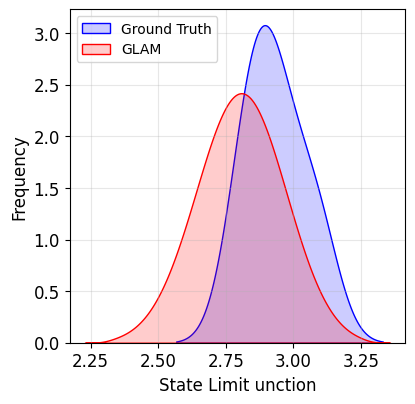

In [58]:
# Figure dimension ans properties
width_cm = 11
height_cm = 11
inches_per_cm = 1 / 2.54
width_in = width_cm * inches_per_cm
height_in = height_cm * inches_per_cm
label_size = 12
axis_size = 12
legend_size = 10
label_color = 'black'

# Plot first KDE with specific color
plt.figure(figsize=(width_in, height_in))

# Ground Truth
sns.kdeplot(data=ratio_data, fill=True, alpha=0.2, color='blue', label='Ground Truth')

# GLAM
sns.kdeplot(data=glam_data, fill=True, alpha=0.2, color='red', label='GLAM')

plt.tick_params(axis='both', which='major', labelsize=axis_size)
plt.xlabel(y_axis_label, fontsize=label_size, color=label_color)
plt.ylabel('Frequency', fontsize=label_size, color=label_color)
plt.grid(alpha=0.3)
plt.legend(fontsize=legend_size, loc='upper left')
plt.show()
# plt.savefig('compare_GLAM_and_GROUNDTRUTH.png', dpi=600)